Задание 1 - 30 баллов
Сформулировать постановку задачу, которую хочется решать в рамках курса.
Критерии оценки:

Сформулирована бизнес-постановка задачи (например, реализовать спам/не спам детектор) - 3 балла
Сформулирована постановка ML-задачи (бинарная классификация) - 2 балла
Представлен набор данных, достаточный для решения поставленной задачи - 3 балла
Выбрать и обосновать метрику для измерения качества.
В рамках данного пункта необходимо подобрать наиболее релевантную метрику или набор метрик для вашей задачи, написав краткое обоснование (1-2 предложения).

Критерии оценки:

Предложена метрика - 3 балла
Присутствует корректное обоснование - 5 баллов
Дополнительный материал о выборе метрик и связи этого процесса с бизнес-постановкой задачи: https://habr.com/ru/company/jetinfosystems/blog/420261/

Провести EDA на своих данных
В рамках данного пункта необходимо провести предварительный разведочный анализ своего набора данных.

Критерии оценки:

Рассмотрены базовые характеристики/статистики для набора данных - 3 балла
Реализованы наиболее релевантные визуализации - 5 баллов
По ходу работы присутствуют комментарии (вы, как эксперт в предметной области, можете проинтерпретировать полученные результаты анализа, визуализации, расcчитанные статистики, сделав выводы о том, каким образом лучше работать с набором данных в будущем, какие могут возникнуть проблемы, какую предобработку целесообразно сделать и тп). - 6 баллов
Предполагается, что студенты среди прочего продемонстрируют использование библиотек для визуализации, рассматриваемых в курсе (seaborn, plotly).


#1
**Бизнес-постановка задачи:**

Выбор и описание бизнес-задачи:


Проблема: В условиях высокой конкуренции на рынке труда компании стремятся удерживать ценных сотрудников и снижать текучесть кадров. Выгорание сотрудников приводит к снижению производительности, нарушению баланса работы и отдыха, а зачастую к увольнению. Выгорание сотрудников увеличивает риск затрат на рекрутинг и обучение новых сотрудников, а также снижает уровень мотивации и удовлетворенности работающих сотрудников

Цель: Разработка системы анализа и предсказания уровня выгорания для оперативного реагирования и принятия мер по удержанию сотрудника в компании

**ML-Постановка задачи**

Цель: Реализовать модель машинного обучения для предсказания уровня выгорания работников и классификации текущего состояния работника (Есть выгорание/ Нет выгорания)

Тип задачи: Классификация
Целевая переменная: Attrition (выгорание) (Да/Нет), которая показывает, уволился ли сотрудник, что может служить индикатором завершившегося выгорания
Если целевая метрика снижается, то количество сотрудников с признаками выгорания становиться ниже, а значит возможно снижение риск увольнения сотрудника, а также есть возможность повышения уровня удовлетворенности с течением времени


**Данные:**

Личные и профессиональные характеристики: возраст, образование, должность, отдел, семейное положение (могут влиять на уровень выгорания и удовлетворенность).

Рабочие условия и вовлеченность: уровень удовлетворенности, баланс работы и личной жизни, участие в обучении (поддержка карьерного развития и личностного роста снижает вероятность выгорания).

Показатели нагрузки: часы переработки, частота командировок (влияют на эмоциональную и физическую нагрузку)

Ссылка на данные: https://www.kaggle.com/datasets/rishikeshkonapure/hr-analytics-prediction/data

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('HR-Employee-Attrition.csv')
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


#2

**Выбор метрики**

Accuracy (Аккуратность) — позволит понять общее качество предсказания, выгорел сотрудник или нет

Precision (точность)  и Recall (полнота) — позволят точнее выявлять сотрудников, склонных к выгоранию (Recall особенно важен для поиска всех случаев потенциального выгорания)


F1-score — для баланса между точностью и полнотой предсказания, как универсальная метрика для оценки модели в целом


Поэтому я буду использовать Accuracy для понимания качества классификации с которой работает моя модель.

#3

EDA

Проведем предварительный анализ данных, в котором высясним количество дубликатов, уникальных значений, уберем значения, которые не являются весомыми с точки зрения влияния на результаты, тем самым оптимизируем объем данных с которыми будем работать

In [ ]:
# Узнаем что в дата сете нет нулевых значений, приятно
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
# Понимаем что в нашем датасете нет дубликатов, это хорошо :)
df.duplicated().sum()

0

In [ ]:
# Сам в шоке от того что делаю, попытаемся найти уникальные значения и неуникальные, для того чтобы вытащить те, что не будут применяться в дальнейшем анализе
def get_unique(a):
  return a.unique()
unique = df.apply(get_unique)

In [ ]:
# Опиши что и почему убрал, потом перейди к визуализации плотли
unique

,0
Age,"[41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 2..."
Attrition,"[Yes, No]"
BusinessTravel,"[Travel_Rarely, Travel_Frequently, Non-Travel]"
DailyRate,"[1102, 279, 1373, 1392, 591, 1005, 1324, 1358,..."
Department,"[Sales, Research & Development, Human Resources]"
DistanceFromHome,"[1, 8, 2, 3, 24, 23, 27, 16, 15, 26, 19, 21, 5..."
Education,"[2, 1, 4, 3, 5]"
EducationField,"[Life Sciences, Other, Medical, Marketing, Tec..."
EmployeeCount,[1]
EmployeeNumber,"[1, 2, 4, 5, 7, 8, 10, 11, 12, 13, 14, 15, 16,..."


Мы можем увидеть что ряд значений так EmployeeCount, EmployeeNumber, Over18,StandardHours имеют значения которые не являются уникальными или имеют всего 2 значения, которые не несут в себе существенной для дальнейшего анализа информации, поэтому мы удалим их




In [ ]:
df=df.drop(['EmployeeCount','EmployeeNumber','Over18','StandardHours'], axis=1)
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


Мы можем наблюдать, что в нашей текеущей ситуации в компании 237 человек с выгоранием относительнообщего числа сотрудников

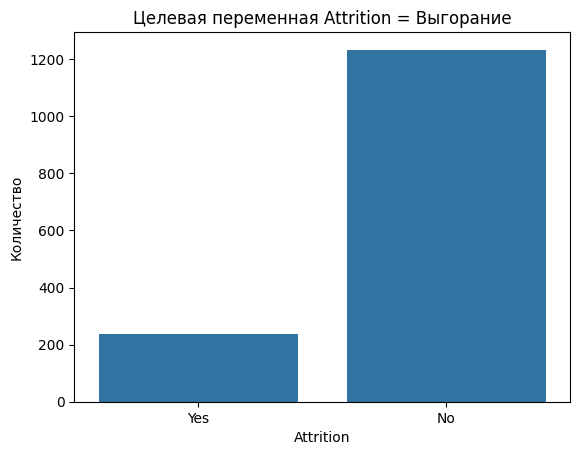

,count
Attrition,
No,1233
Yes,237


In [ ]:
# Построение графика для переменной x='Attrition'
sb.countplot(data=df, x='Attrition')
plt.title('Целевая переменная Attrition = Выгорание')
plt.ylabel('Количество')
count=df['Attrition'].value_counts()
plt.show()
count

Мы можем увидеть что как и ожидалось связь существует, а основные случаи выгорания происходят с людми с доходом ниже 11000, хотя есть и отдельные случаи выгорания при большем уровне дохода

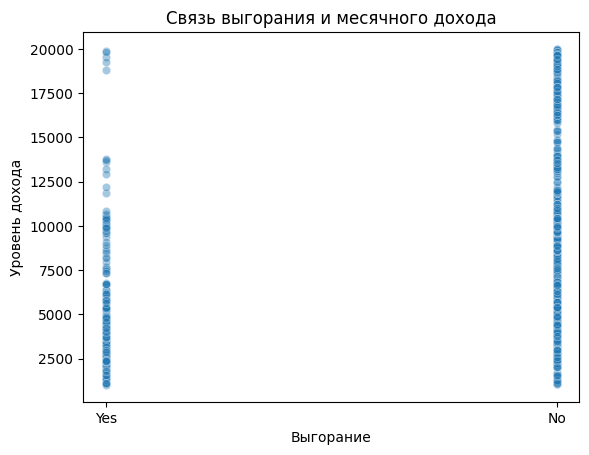

In [ ]:
# Попробуем выяснить зависимость выгорания и месячного дохода, потому что сходу кажется что эти данные могу коррелировать
sb.scatterplot(x='Attrition', y='MonthlyIncome', data=df, alpha=0.4)
plt.title('Связь выгорания и месячного дохода')
plt.xlabel('Выгорание')
plt.ylabel('Уровень дохода')
plt.show()

Сделаем визуализацию для всех данных имеющих тип 'object' для того чтобы наглядно посмотреть на данные

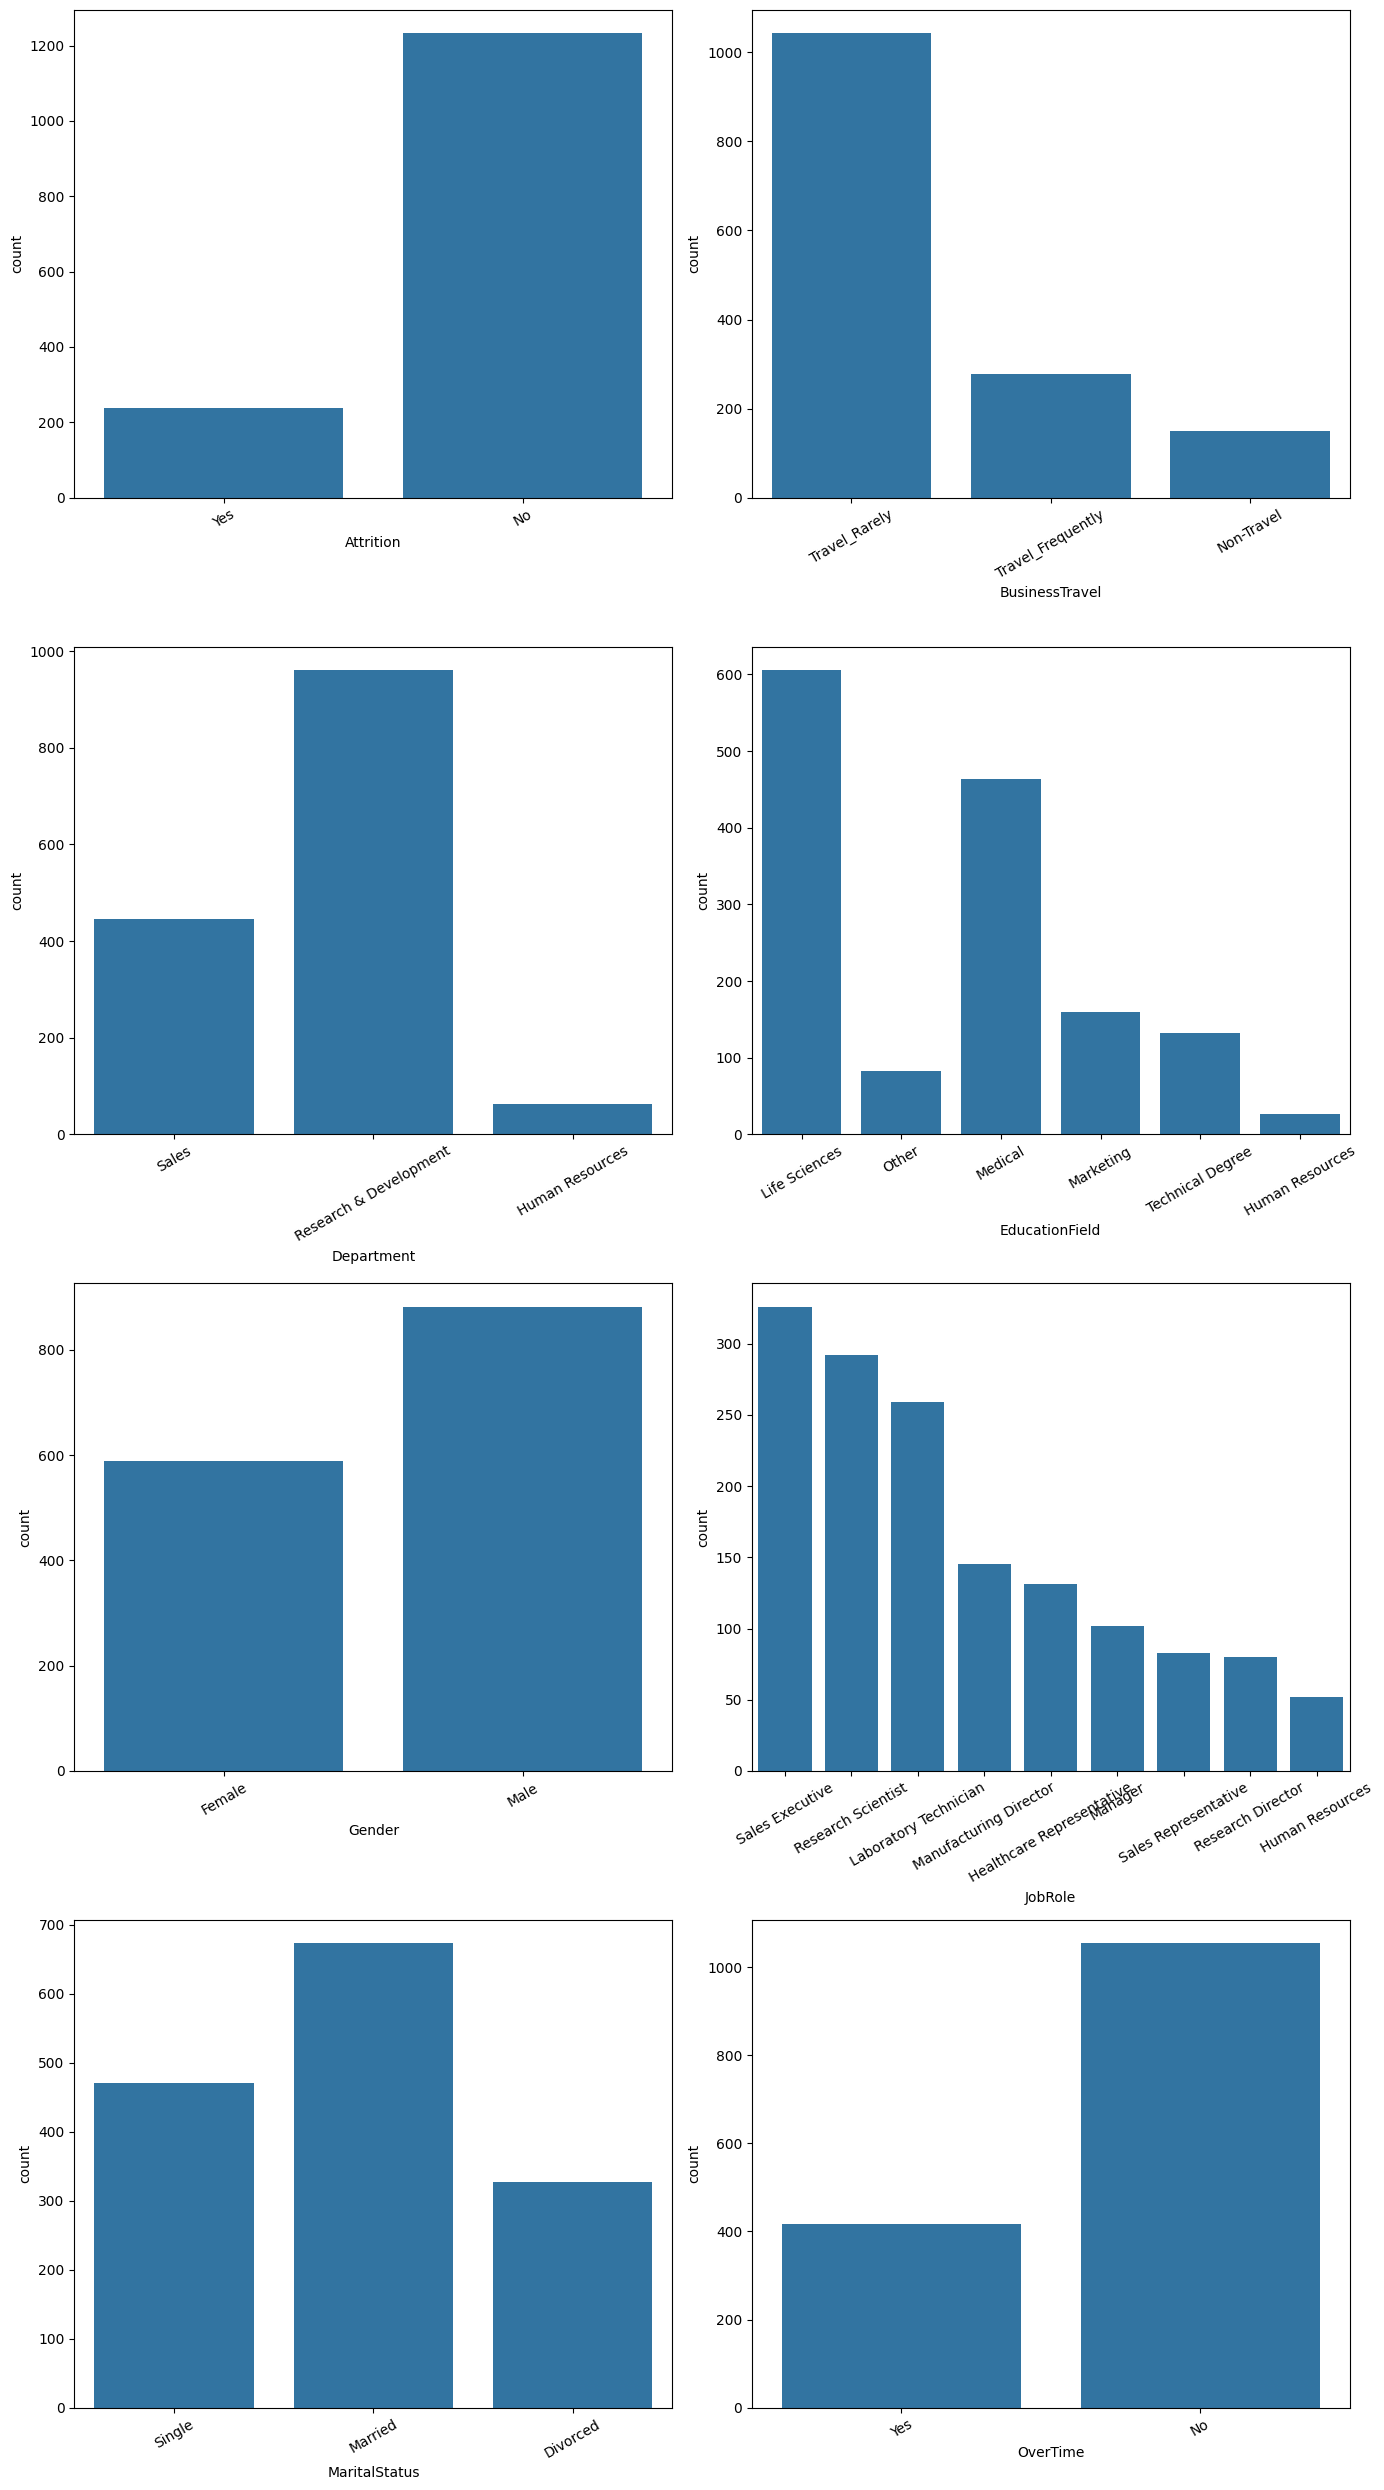

In [ ]:
objесtdata = df.select_dtypes(include = 'object')

plt.figure(figsize=(14,25))
for i,col in enumerate(objесtdata):
    axes = plt.subplot(4,2, i + 1)
    sb.countplot(x=df[col])
    plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

Построим HeatMap для числовых переменных в формате (int), чтобы определить возможные корреляции признаков для будущего рассмотрения

<Axes: >

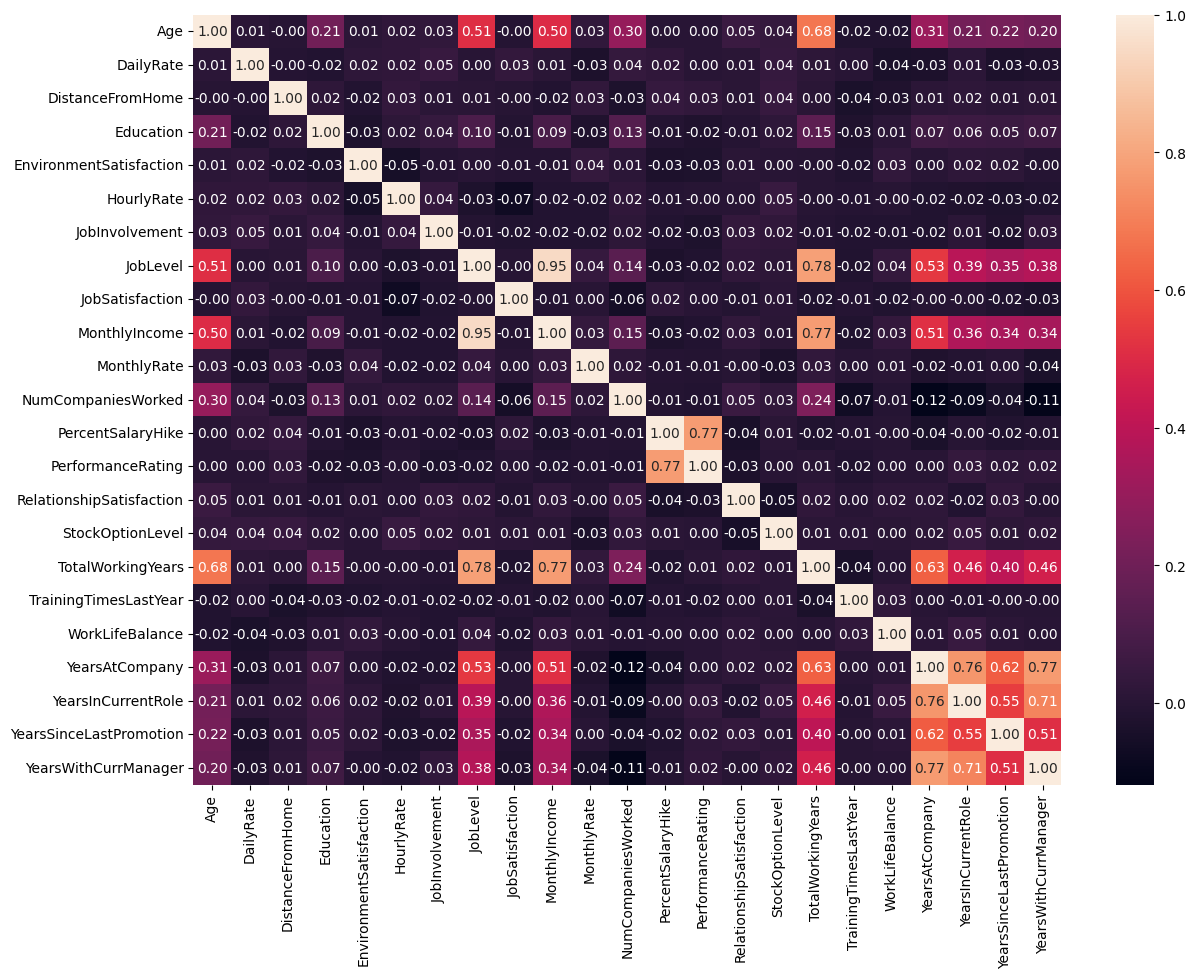

In [ ]:
correlation = df.select_dtypes(np.number).corr()
plt.figure(figsize=(14,10))
sb.heatmap(correlation, annot=True, fmt='.2f')

Оставим переменные которые коррелируют между собой наиболее сильно, а именно:


*   Age
*   JobLevel
* MonthlyIncome
* NumCompaniesWorked
* TotalWorkingYears
* YearsAtCompany
* YearsInCurrentRole
* YearsSinceLastPromotion
* YearsWithCurrManager




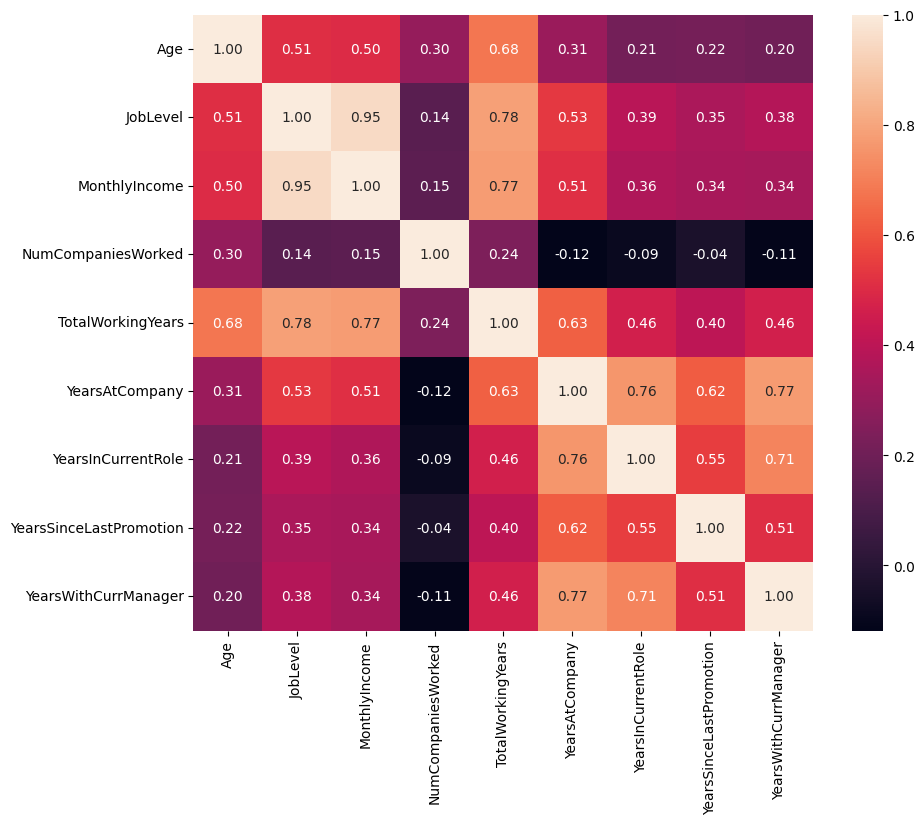

In [ ]:
correlation2 = df[['Age','JobLevel','MonthlyIncome','NumCompaniesWorked','TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']].corr()
plt.figure(figsize=(10,8))
sb.heatmap(correlation2,fmt='.2f',annot=True)
plt.show()

**Наблюдения:**

В компании 237 человек с признаком выгорания

Есть взаимосвязь между Месячным доходом и выгоранием, интерес представляет группа людей с большим доходом и выгоранием, необходимо будет подумать какой из признаков влияет на эту категорию сотрудников

Результаты использования HeatMap
---



Мы смогли найти и установить корреляцию следующих числовых признаков
*   Age
*   JobLevel
* MonthlyIncome
* NumCompaniesWorked
* TotalWorkingYears
* YearsAtCompany
* YearsInCurrentRole
* YearsSinceLastPromotion
* YearsWithCurrManager

В дальнейшем уделим им особое внимание